In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Load Data

In [5]:
df = pd.read_csv(r"C:\Users\Nada\Data-Science\data\events.csv")

In [6]:
df.head()

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2020-09-24 11:57:06 UTC,view,1996170,2144415922528452715,electronics.telephone,NaN,31.90,1515915625519388267,LJuJVLEjPT
1,2020-09-24 11:57:26 UTC,view,139905,2144415926932472027,computers.components.cooler,zalman,17.16,1515915625519380411,tdicluNnRY
2,2020-09-24 11:57:27 UTC,view,215454,2144415927158964449,NaN,NaN,9.81,1515915625513238515,4TMArHtXQy
3,2020-09-24 11:57:33 UTC,view,635807,2144415923107266682,computers.peripherals.printer,pantum,113.81,1515915625519014356,aGFYrNgC08
4,2020-09-24 11:57:36 UTC,view,3658723,2144415921169498184,NaN,cameronsino,15.87,1515915625510743344,aa4mmk0kwQ


In [7]:
df.shape

(885129, 9)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 885129 entries, 0 to 885128
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_time     885129 non-null  str    
 1   event_type     885129 non-null  str    
 2   product_id     885129 non-null  int64  
 3   category_id    885129 non-null  int64  
 4   category_code  648910 non-null  str    
 5   brand          672765 non-null  str    
 6   price          885129 non-null  float64
 7   user_id        885129 non-null  int64  
 8   user_session   884964 non-null  str    
dtypes: float64(1), int64(3), str(5)
memory usage: 60.8 MB


In [9]:
df.isnull().sum()

event_time            0
event_type            0
product_id            0
category_id           0
category_code    236219
brand            212364
price                 0
user_id               0
user_session        165
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(655)

## 2. Data Cleaning

- Remove duplicate records
- Handle missing values
- Convert `event_time` to datetime
- Validate categorical values
- Check price validity
- Check consistency between IDs and their attributes

In [11]:
df = df.drop_duplicates().reset_index(drop=True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.dropna(subset=["user_session"])

In [14]:
df["event_time"] = pd.to_datetime(df["event_time"], utc=True)

In [15]:
df.info()

<class 'pandas.DataFrame'>
Index: 884312 entries, 0 to 884473
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype              
---  ------         --------------   -----              
 0   event_time     884312 non-null  datetime64[us, UTC]
 1   event_type     884312 non-null  str                
 2   product_id     884312 non-null  int64              
 3   category_id    884312 non-null  int64              
 4   category_code  648311 non-null  str                
 5   brand          672118 non-null  str                
 6   price          884312 non-null  float64            
 7   user_id        884312 non-null  int64              
 8   user_session   884312 non-null  str                
dtypes: datetime64[us, UTC](1), float64(1), int64(3), str(4)
memory usage: 67.5 MB


In [16]:
df["event_type"].value_counts()

event_type
view        792943
cart         54026
purchase     37343
Name: count, dtype: int64

In [17]:
df["price"].describe()

count    884312.000000
mean        146.324856
std         296.857302
min           0.220000
25%          26.460000
50%          65.710000
75%         190.540000
max       64771.060000
Name: price, dtype: float64

In [18]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower:", lower)
print("Upper:", upper)
print("Outliers:", ((df["price"] < lower) | (df["price"] > upper)).sum())

Lower: -219.65999999999997
Upper: 436.65999999999997
Outliers: 66242


In [19]:
df.nlargest(20, "price")[["product_id", "category_code", "brand", "price"]]

,product_id,category_code,brand,price
51235,4170916,computers.peripherals.monitor,lg,64771.06
86257,4170916,computers.peripherals.monitor,lg,64771.06
418413,4170916,computers.peripherals.monitor,lg,64771.06
627091,4170916,computers.peripherals.monitor,lg,64771.06
298486,4078837,electronics.video.tv,samsung,42590.13
324337,4078837,electronics.video.tv,samsung,42590.13
395010,4078837,electronics.video.tv,samsung,42590.13
865939,4078837,electronics.video.tv,samsung,42590.13
13632,4078834,electronics.video.tv,samsung,27775.87
20019,4078834,electronics.video.tv,samsung,27775.87


### Outliers

Price outliers were identified using the IQR method
they weren't removed because the extreme values correspond to legitimate high-priced
products such as TVs

In [20]:
print("Minimum price:", df["price"].min())
print("Negative prices:", (df["price"] < 0).sum())
print("Zero prices:", (df["price"] == 0).sum())

Minimum price: 0.22
Negative prices: 0
Zero prices: 0


In [21]:
df.groupby("product_id")["category_id"].nunique().max()

np.int64(1)

In [22]:
df.groupby("category_id")["category_code"].nunique().max()

np.int64(1)

In [23]:
df.groupby("product_id")["price"].nunique().max()

np.int64(1)

In [24]:
session_user_check = df.groupby("user_session")["user_id"].nunique()
session_user_check[session_user_check > 1].sort_values(ascending=False).head(20)

user_session
RpTf6e9Fb2                              12
OqGPDFfwQe                               4
BQqWNdnvsL                               3
Bq4rpaW3yG                               3
0vbUoys47h                               3
88ChsOK5Fu                               3
aFnzij6pU7                               3
ae6036bb-ddd3-46a6-a255-c398cb6a5f42     3
lF5qdiWO50                               3
ea2551ff-1346-4f7c-9cfb-75cbd365bfcb     3
GdrOXp4faG                               3
0zHztrq8AI                               2
0pESzPRN0O                               2
1W9orV3oGs                               2
1d80bd83-b357-466a-bbc1-31b070603a62     2
1gTReHhoMa                               2
127884c9-81d8-40be-bf66-0de00794ffeb     2
17828a7c-67b9-4dac-807c-02e0fac87e40     2
1JRWgWDNUx                               2
1LqICZ2ogc                               2
Name: user_id, dtype: int64

In [25]:
multi_user_sessions = (session_user_check > 1).sum()
print("Sessions with multiple users:", multi_user_sessions)
print("Percentage:", multi_user_sessions / df["user_session"].nunique() * 100)

Sessions with multiple users: 214
Percentage: 0.043638024624896514


### Data Quality Note

A very small proportion of sessions (0.0436%) were associated with more than
one user
These records were retained because the issue represents a very
small portion of the dataset and removing them could lead to unnecessary
data loss

## Exploratory Data Analysis (EDA)

### 1. Customer Funnel

We first examine the distribution of different event types to understand
how users interact with products on the platform

In [100]:
event_counts = df["event_type"].value_counts()

event_counts

event_type
view        792943
cart         54026
purchase     37343
Name: count, dtype: int64

In [101]:
funnel_data = pd.Series({
    "View": event_counts["view"],
    "Cart": event_counts["cart"],
    "Purchase": event_counts["purchase"]
})

funnel_data

View        792943
Cart         54026
Purchase     37343
dtype: int64

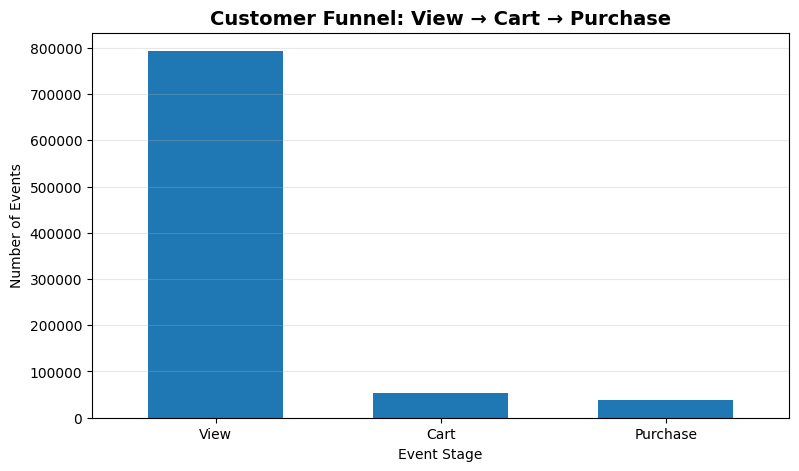

In [102]:
plt.figure(figsize=(9, 5))

funnel_data.plot(
    kind="bar",
    width=0.6
)

plt.title(
    "Customer Funnel: View → Cart → Purchase",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Event Stage")
plt.ylabel("Number of Events")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "C:/Users/Nada/Data-Science/outputs/customer_funnel.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
view_to_cart = event_counts["cart"] / event_counts["view"] * 100
cart_to_purchase = event_counts["purchase"] / event_counts["cart"] * 100
view_to_purchase = event_counts["purchase"] / event_counts["view"] * 100

print(f"View → Cart: {view_to_cart:.2f}%")
print(f"Cart → Purchase: {cart_to_purchase:.2f}%")
print(f"View → Purchase: {view_to_purchase:.2f}%")

View → Cart: 6.81%
Cart → Purchase: 69.12%
View → Purchase: 4.71%


### 2. User Analysis

This section analyzes user activity across different event types to understand how users interact with the platform and how many users reach each stage of the purchasing journey

event_counts
→ How many events happened?

user_events
→ How many unique users performed each event?

In [35]:
user_events = df.groupby("event_type")["user_id"].nunique()
user_events

event_type
cart         36948
purchase     21304
view        406817
Name: user_id, dtype: int64

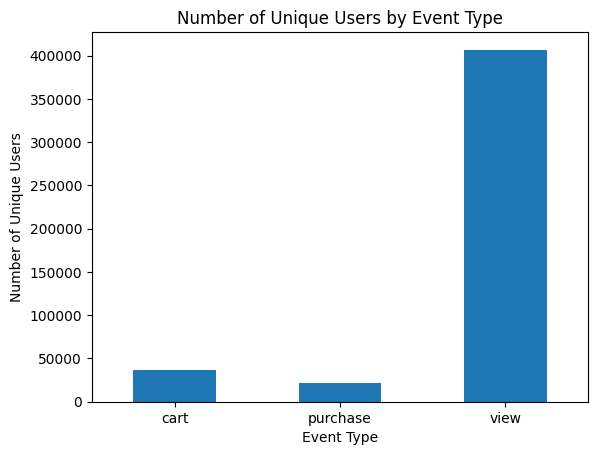

In [37]:
user_events.plot(kind="bar")
plt.title("Number of Unique Users by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Number of Unique Users")
plt.xticks(rotation=0)
plt.savefig(
    r"C:\Users\Nada\Data-Science\outputs\unique_users.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### 3. Product Analysis

This section analyzes product-level activity to identify the most viewed,
most added-to-cart, and most purchased products.

In [38]:
top_viewed_products = (df[df["event_type"] == "view"].groupby("product_id").size().sort_values(ascending=False)
                       .head(10)
)

top_viewed_products

product_id
1821813    12793
3791351     5715
4099645     5489
1785245     4629
3829355     4552
809948      3830
1830099     3660
3791509     3150
4154414     3000
893196      2865
dtype: int64

In [39]:
top_cart_products = (df[df["event_type"] == "cart"].groupby("product_id").size().sort_values(ascending=False)
    .head(10)
)

top_cart_products

product_id
1821813    1220
4099645    1033
3791351     761
3829355     664
893196      662
4102739     492
4154414     450
4079420     370
1830099     369
3642540     318
dtype: int64

In [40]:
top_purchased_products = (df[df["event_type"] == "purchase"].groupby("product_id").size().sort_values(ascending=False)
    .head(10)
)

top_purchased_products

product_id
4099645    564
3829355    543
1821813    538
3791351    423
893196     384
3642540    345
4102739    266
287525     261
4154414    257
246841     242
dtype: int64

In [41]:
product_comparison = pd.DataFrame({
    "Views": top_viewed_products,
    "Cart": top_cart_products,
    "Purchases": top_purchased_products
}).fillna(0)

product_comparison

,Views,Cart,Purchases
product_id,,,
246841,0.0,0.0,242.0
287525,0.0,0.0,261.0
809948,3830.0,0.0,0.0
893196,2865.0,662.0,384.0
1785245,4629.0,0.0,0.0
1821813,12793.0,1220.0,538.0
1830099,3660.0,369.0,0.0
3642540,0.0,318.0,345.0
3791351,5715.0,761.0,423.0


In [42]:
top_viewed_comparison = product_comparison.loc[top_viewed_products.index]
top_viewed_comparison

,Views,Cart,Purchases
product_id,,,
1821813,12793.0,1220.0,538.0
3791351,5715.0,761.0,423.0
4099645,5489.0,1033.0,564.0
1785245,4629.0,0.0,0.0
3829355,4552.0,664.0,543.0
809948,3830.0,0.0,0.0
1830099,3660.0,369.0,0.0
3791509,3150.0,0.0,0.0
4154414,3000.0,450.0,257.0


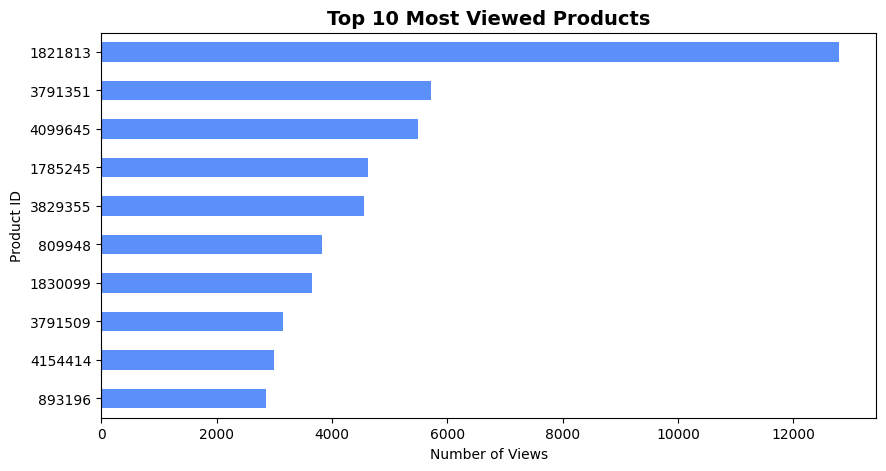

In [78]:
top_viewed_products.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#5B8FF9"
)

plt.title("Top 10 Most Viewed Products", fontsize=14, fontweight="bold")
plt.xlabel("Number of Views")
plt.ylabel("Product ID")
plt.savefig(
    r"C:\Users\Nada\Data-Science\outputs\Product_Analysis\top_viewedproducts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

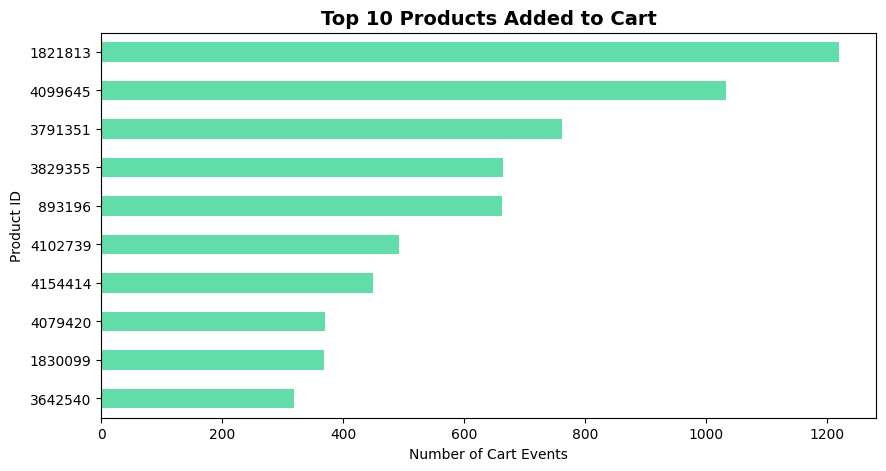

In [77]:
top_cart_products.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#61DDAA"
)

plt.title("Top 10 Products Added to Cart", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cart Events")
plt.ylabel("Product ID")
plt.savefig(
    r"C:\Users\Nada\Data-Science\outputs\Product_Analysis\top_cartproducts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

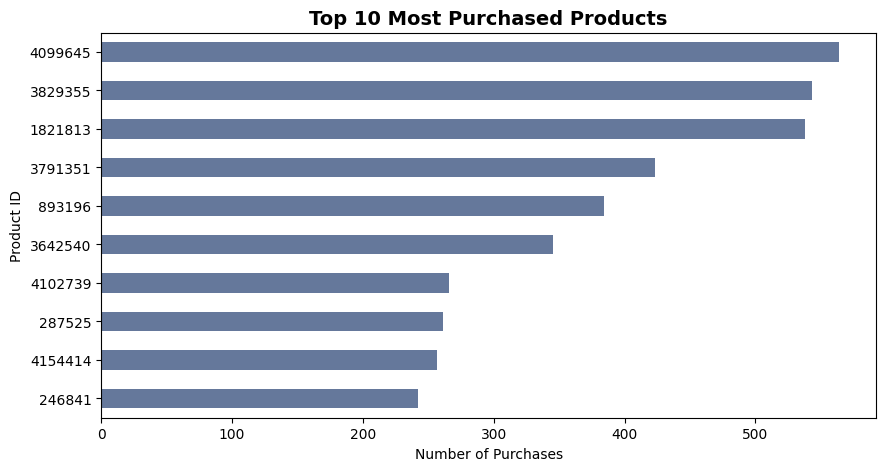

In [76]:
top_purchased_products.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#65789B"
)

plt.title("Top 10 Most Purchased Products", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Product ID")
plt.savefig(
    r"C:\Users\Nada\Data-Science\outputs\Product_Analysis\top_purchasedproducts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Key Insights

- Product **1821813** is the most viewed product by a large margin.
- Product **4099645** has the highest number of purchases, despite not having the highest number of views.
- Products **1821813, 4099645, 3829355, and 3791351** show strong activity across the different stages of the customer journey.
- Some highly viewed products, such as **1785245** and **809948**, do not appear among the top purchased products, suggesting that high visibility does not always lead to high purchase activity.

### 4. Category Analysis

This section analyzes product categories to identify the categories with the highest levels of views, cart activity, and purchases.

In [89]:
top_viewed_categories = (
    df[
        (df["event_type"] == "view") &
        (df["category_level_1"] != "unknown")
    ]
    .groupby("category_level_1")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_viewed_categories

category_level_1
computers       272808
electronics     155125
appliances       38938
stationery       36796
auto             32858
construction     28674
furniture         3093
country_yard      3072
accessories       1953
medicine           682
dtype: int64

In [90]:
top_cart_categories = (
    df[
        (df["event_type"] == "cart") &
        (df["category_level_1"] != "unknown")
    ]
    .groupby("category_level_1")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_cart_categories

category_level_1
computers       26982
electronics      9056
stationery       3233
auto             1459
construction     1362
appliances       1205
furniture         156
accessories        66
country_yard       42
medicine           19
dtype: int64

In [91]:
top_purchased_categories = (
    df[
        (df["event_type"] == "purchase") &
        (df["category_level_1"] != "unknown")
    ]
    .groupby("category_level_1")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_purchased_categories

category_level_1
computers       16870
electronics      6768
stationery       2919
auto             1091
construction      999
appliances        904
furniture         115
accessories        56
country_yard       23
medicine           11
dtype: int64

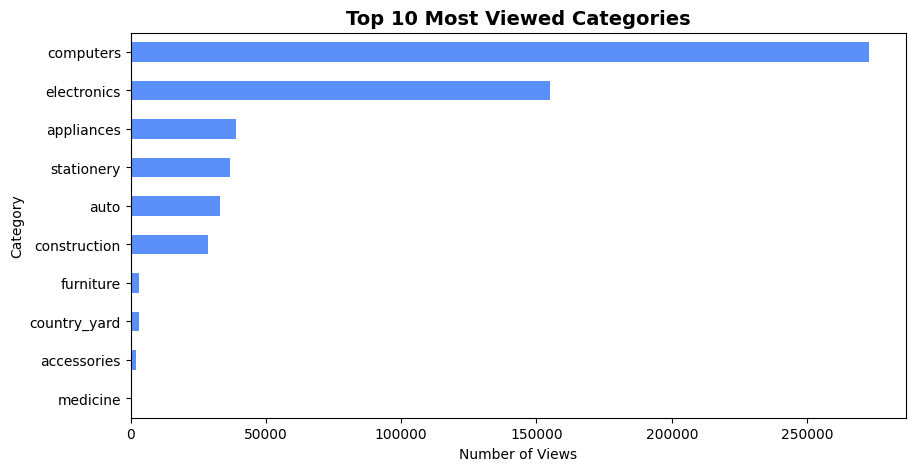

In [92]:
top_viewed_categories.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#5B8FF9"
)

plt.title("Top 10 Most Viewed Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Views")
plt.ylabel("Category")
plt.show()

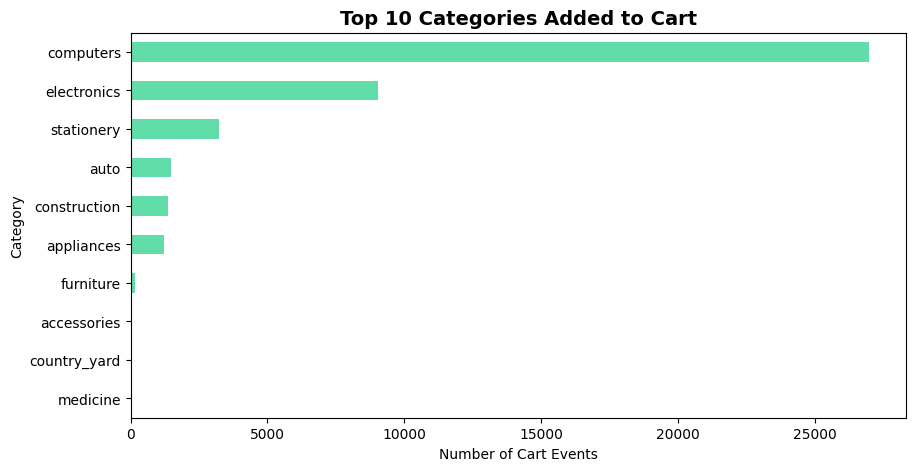

In [93]:
top_cart_categories.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#61DDAA"
)

plt.title("Top 10 Categories Added to Cart", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cart Events")
plt.ylabel("Category")
plt.show()

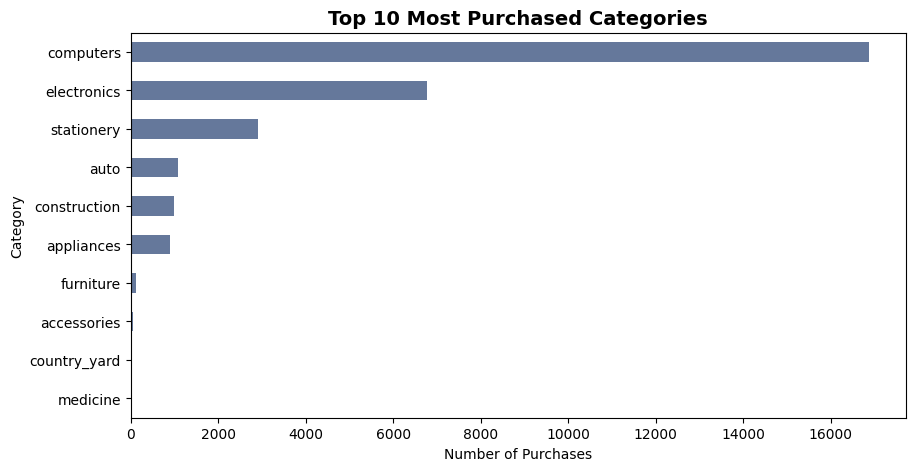

In [94]:
top_purchased_categories.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#65789B"
)

plt.title("Top 10 Most Purchased Categories", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()

### Key Insights

- **computers.components.videocards** is the most active category across views, cart additions, and purchases.
- **electronics.telephone** consistently ranks second across the three event types.
- **stationery.cartrige** shows strong purchase activity, ranking third in purchases despite having fewer views than some other categories.
- The categories with high view activity generally maintain strong cart and purchase activity, indicating consistent customer interest.

### 5. Brand Analysis

This section analyzes brand-level activity to identify the brands with the highest levels of views, cart activity, and purchases.

In [58]:
top_viewed_brands = (
    df[df["event_type"] == "view"]
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_viewed_brands

brand
asus         24268
gigabyte     22759
palit        21468
samsung      21392
msi          19940
amd          17173
canon        16033
panasonic    11321
pioneer      10155
sirius        9762
dtype: int64

In [59]:
top_cart_brands = (
    df[df["event_type"] == "cart"]
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_cart_brands

brand
gigabyte    3152
msi         3135
palit       2241
asus        2128
amd         1899
sapphire    1440
canon       1351
samsung     1029
sirius       897
asrock       871
dtype: int64

In [60]:
top_purchased_brands = (
    df[df["event_type"] == "purchase"]
    .groupby("brand")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

top_purchased_brands

brand
msi         1788
gigabyte    1741
asus        1261
palit       1077
canon       1045
amd         1020
sapphire     917
samsung      757
sirius       742
hp           691
dtype: int64

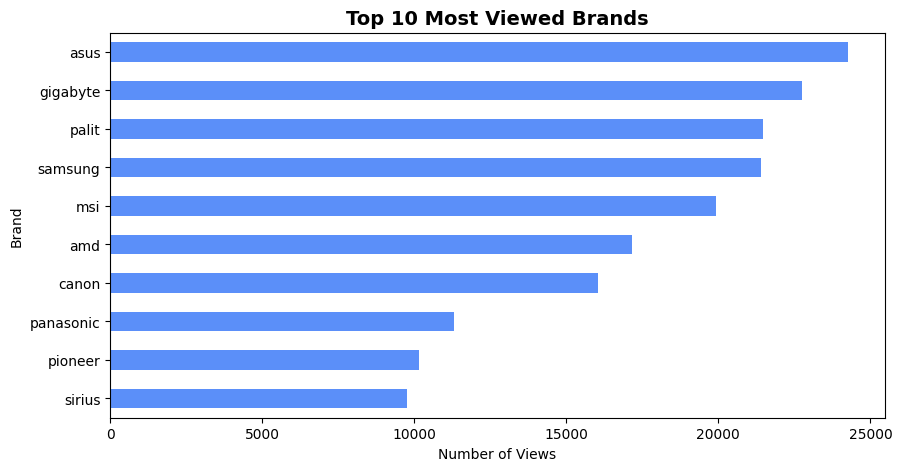

In [61]:
top_viewed_brands.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#5B8FF9"
)

plt.title("Top 10 Most Viewed Brands", fontsize=14, fontweight="bold")
plt.xlabel("Number of Views")
plt.ylabel("Brand")
plt.show()

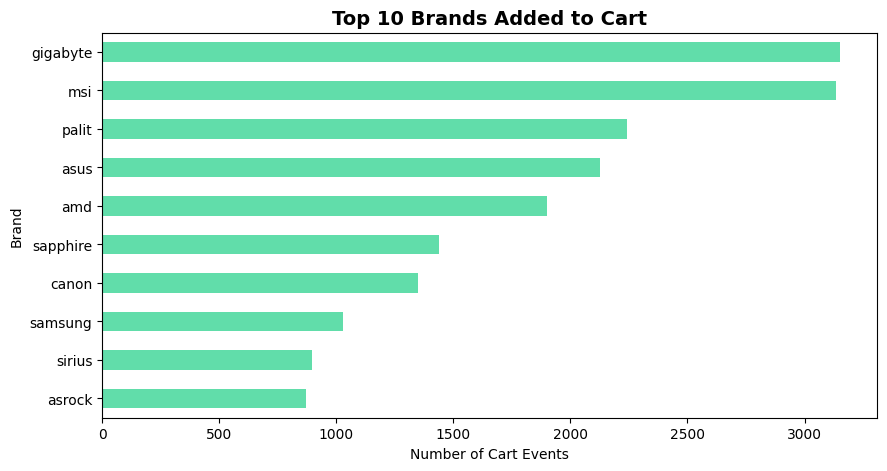

In [62]:
top_cart_brands.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#61DDAA"
)

plt.title("Top 10 Brands Added to Cart", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cart Events")
plt.ylabel("Brand")
plt.show()

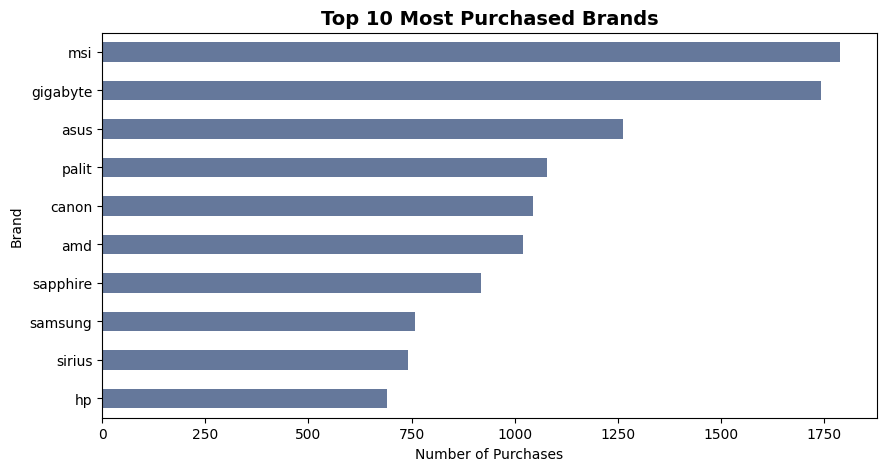

In [63]:
top_purchased_brands.sort_values().plot(
    kind="barh",
    figsize=(10, 5),
    color="#65789B"
)

plt.title("Top 10 Most Purchased Brands", fontsize=14, fontweight="bold")
plt.xlabel("Number of Purchases")
plt.ylabel("Brand")
plt.show()

### Key Insights

- **MSI** has the highest number of purchases among the top brands.
- **Gigabyte** has the highest cart activity, while MSI ranks very closely behind.
- **ASUS** has the highest number of views, but does not lead in purchases.
- **MSI, Gigabyte, ASUS, and Palit** consistently appear among the top brands across different event types.
- Overall, strong visibility does not always correspond to the highest purchase activity.

### 6. Time Analysis

This section analyzes user activity over time to identify trends and patterns in views, cart additions, and purchases.

In [64]:
df["date"] = df["event_time"].dt.date

daily_events = (
    df.groupby(["date", "event_type"])
    .size()
    .unstack(fill_value=0)
)

daily_events.head()

event_type,cart,purchase,view
date,,,
2020-09-24,99,84,2079
2020-09-25,240,149,3850
2020-09-26,177,119,3166
2020-09-27,172,110,3567
2020-09-28,259,200,4253


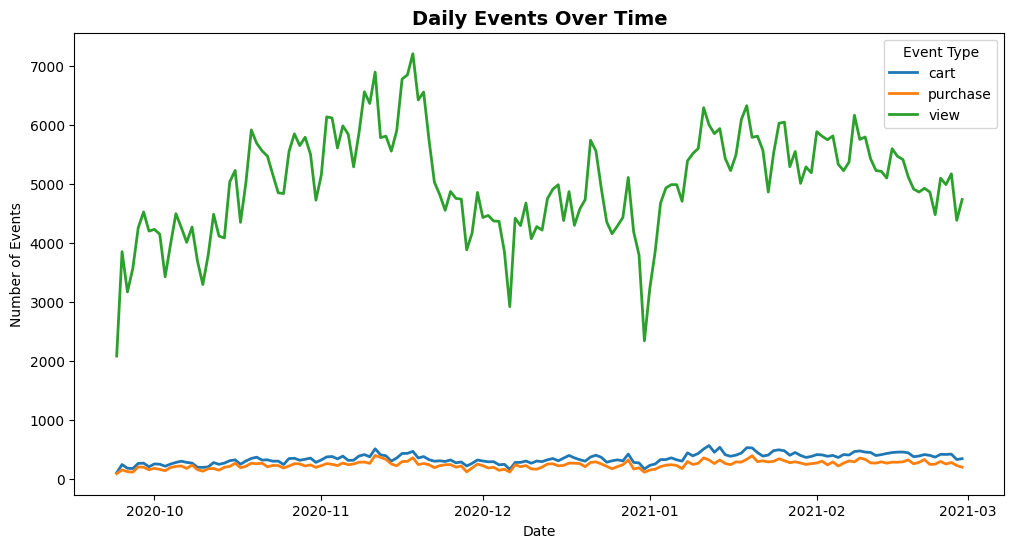

In [65]:
daily_events.plot(
    figsize=(12, 6),
    linewidth=2
)

plt.title("Daily Events Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Number of Events")
plt.legend(title="Event Type")
plt.show()

### Key Insights

- Views consistently represent the largest share of daily events throughout the period.
- Cart and purchase activities generally follow the overall trend of user activity.
- Daily activity shows noticeable fluctuations, with several peaks and drops over time.
- A significant drop in activity appears around the beginning of January, followed by a recovery.
- November shows relatively high levels of activity, with several noticeable peaks.

#### Events by Hour

This analysis identifies the hours with the highest and lowest levels of user activity.

In [66]:
df["hour"] = df["event_time"].dt.hour

hourly_events = (
    df.groupby(["hour", "event_type"])
    .size()
    .unstack(fill_value=0)
)

hourly_events

event_type,cart,purchase,view
hour,,,
0,584,361,9346
1,532,328,9085
2,612,403,10152
3,907,575,13771
4,1169,788,19012
5,1829,1165,26742
6,2421,1691,35462
7,2953,2000,41973
8,3070,2215,44614


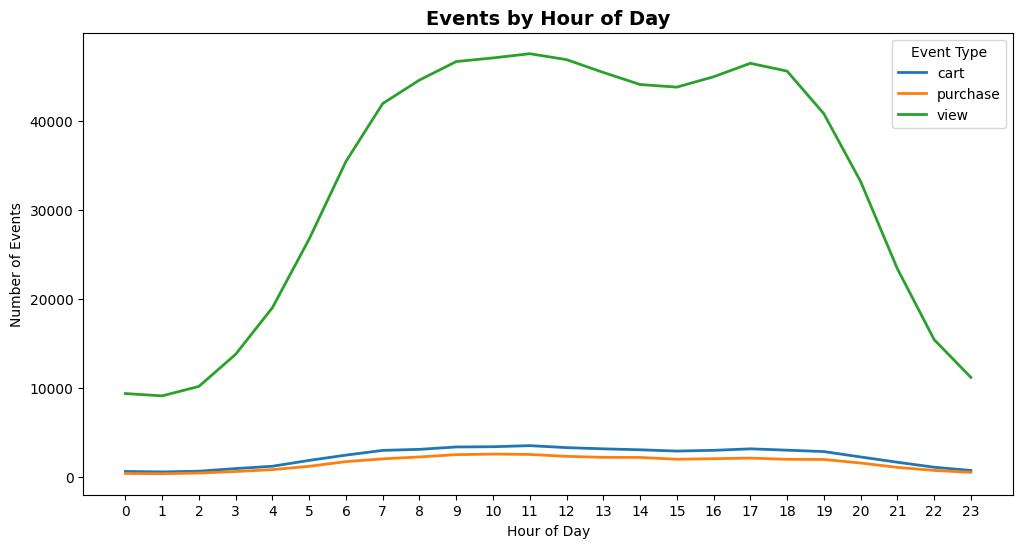

In [67]:
hourly_events.plot(
    figsize=(12, 6),
    linewidth=2
)

plt.title("Events by Hour of Day", fontsize=14, fontweight="bold")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.xticks(range(24))
plt.legend(title="Event Type")
plt.show()

### Key Insights

- User activity is lowest during the early morning hours.
- Activity increases gradually from around 4 AM and reaches its highest levels during the late morning.
- Views peak around **11 AM**, while both cart additions and purchases peak around **10 AM**.
- Overall activity decreases after the afternoon, with a moderate increase around the early evening.

### 7. Price Analysis

This section examines the distribution of product prices and explores how price levels vary across customer events.

In [68]:
df["price"].describe()

count    884312.000000
mean        146.324856
std         296.857302
min           0.220000
25%          26.460000
50%          65.710000
75%         190.540000
max       64771.060000
Name: price, dtype: float64

In [69]:
avg_price_by_event = (
    df.groupby("event_type")["price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_by_event

event_type
cart        159.653883
view        145.844343
purchase    137.244301
Name: price, dtype: float64

In [70]:
category_price = (
    df.groupby("category_code")["price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

category_price.head(10)

,mean,median,count
category_code,,,
electronics.video.projector,746.564896,578.43,1583
appliances.kitchen.washer,666.670000,666.67,60
electronics.audio.music_tools.piano,436.680531,310.21,414
country_yard.cultivator,429.050209,418.89,2390
computers.components.videocards,385.974310,397.48,116606
computers.peripherals.monitor,375.498069,202.95,6685
electronics.video.tv,353.858700,191.67,21367
kids.skates,334.848010,304.41,196
appliances.kitchen.coffee_machine,330.710331,183.60,3449


In [71]:
cat_split = df["category_code"].str.split(".", expand=True)

cat_split.columns = [
    f"category_level_{i+1}"
    for i in range(cat_split.shape[1])
]

df = pd.concat([df, cat_split], axis=1)

for col in cat_split.columns:
    df[col] = df[col].fillna("unknown")

In [72]:
df[[
    "category_code",
    "category_level_1",
    "category_level_2",
    "category_level_3"
]].head()

,category_code,category_level_1,category_level_2,category_level_3
0,electronics.telephone,electronics,telephone,unknown
1,computers.components.cooler,computers,components,cooler
2,NaN,unknown,unknown,unknown
3,computers.peripherals.printer,computers,peripherals,printer
4,NaN,unknown,unknown,unknown


In [73]:
price_category = (
    df.groupby("category_level_1")
    .agg(
        avg_price=("price", "mean"),
        purchases=("event_type", lambda x: (x == "purchase").sum())
    )
    .sort_values("avg_price", ascending=False)
)

price_category

,avg_price,purchases
category_level_1,,
country_yard,352.481820,23
sport,298.062155,6
computers,224.546733,16870
kids,198.581613,10
appliances,150.493067,904
electronics,126.725042,6768
auto,115.239393,1091
construction,101.448378,999
unknown,83.022242,7566


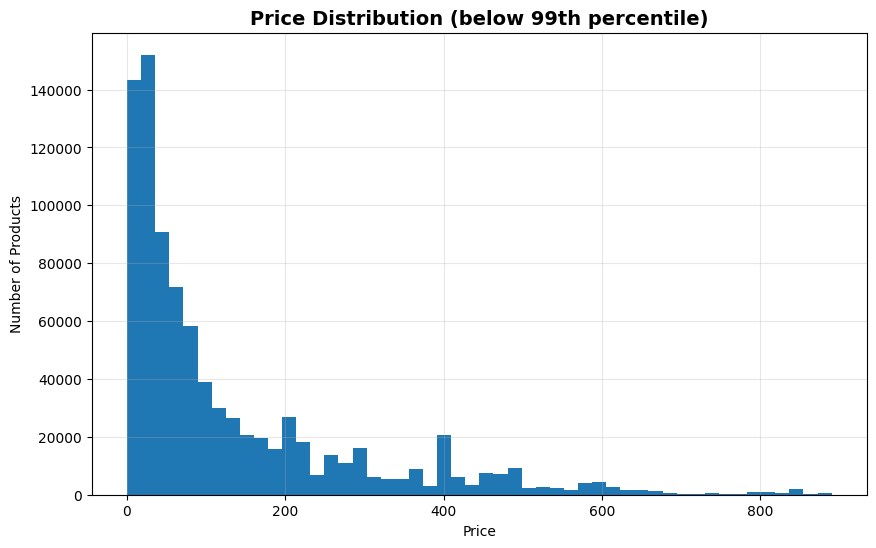

In [74]:
price_99 = df["price"].quantile(0.99)

plt.figure(figsize=(10, 6))

plt.hist(
    df[df["price"] <= price_99]["price"],
    bins=50
)

plt.title("Price Distribution (below 99th percentile)", fontsize=14, fontweight="bold")
plt.xlabel("Price")
plt.ylabel("Number of Products")
plt.grid(alpha=0.3)

plt.show()

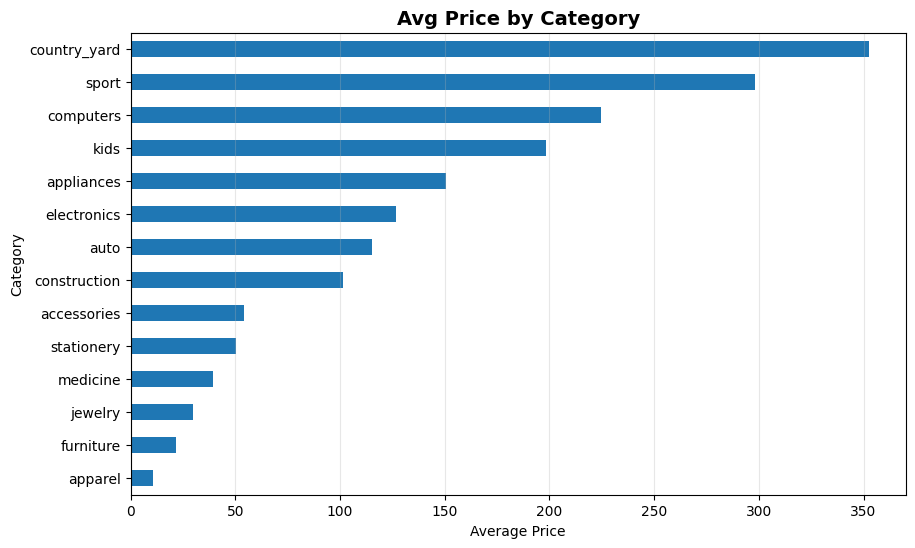

In [95]:
avg_price_by_category = (
    df[df["category_level_1"] != "unknown"]
    .groupby("category_level_1")["price"]
    .mean()
    .sort_values(ascending=True)
)


plt.figure(figsize=(10, 6))

avg_price_by_category.plot(
    kind="barh"
)

plt.title("Avg Price by Category", fontsize=14, fontweight="bold")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.grid(axis="x", alpha=0.3)

plt.show()